# Data Processing with NumPy and Pandas

***Our goal is to analyze Spotify's top hits to quantify what makes a hit song. We are given a csv file of the top 50 tracks, each described by various features. We are now going to process and analyze the given data. During this process we are going to answer various questions.***

#### Overview
Colab Link - https://colab.research.google.com/drive/1wlean5KD-9yxhMl2yYh3__6kS0xGC6av?usp=sharing
- **`Load the data using pandas`**
- **`Perform data cleaning`**
    - Handling missing values.
    - Removing duplicate samples and features.
    - Treating the outliers.
- **`Explatory data analysis`**
    - How many observations are there in this dataset?
    - How many features this dataset has?
    - Which of the features are categorical?
    - Which of the features are numeric?
    - Are there any artists that have more than 1 popular track? If yes, which and how many?
    - Who was the most popular artist?
    - How many artists in total have their songs in the top 50?
    - Are there any albums that have more than 1 popular track? If yes, which and how many?
    - How many albums in total have their songs in the top 50?
    - Which tracks have a danceability score above 0.7?
    - Which tracks have a danceability score below 0.4?
    - Which tracks have their loudness above -5?
    - Which tracks have their loudness below -8?
    - Which track is the longest?
    - Which track is the shortest?
    - Which genre is the most popular?
    - Which genres have just one song on the top 50?
    - How many genres in total are represented in the top 50?
    - Which features are strongly positively correlated?
    - Which features are strongly negatively correlated?
    - Which features are not correlated?
- **`Results overview`**
- **`Interpretation`**
  - What makes a hit song? 
  - Notes

In [1]:
# Importing the necessary modules 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import operator

In [2]:
# Constants 

# Paths to input/output datasets
DATA_PATH = "Dataset/spotifytoptracks.csv"
DATA_PROCESSED_PATH = "Dataset/spotifytoptracks_processed.csv"

# Feature sets used during cleaning
CLIP_FEATURES = ["energy", "danceability", "acousticness", "speechiness", "instrumentalness", "liveness", "valence"]
# We can do IQR handling but not absolutely necessary
IQR_FEATURES = ["loudness", "duration_ms"]

# Text columns for formatting/grouping
STRING_COLUMNS = ["artist", "track_name", "album", "genre"]

# Target genres for feature comparison
TARGET_GENRES = ["Pop", "Hip-Hop/Rap", "Dance/Electronic", "Alternative/Indie"]

## Load the data using pandas

In [3]:
# Reading our dataset as csv and printing head and shape to check whether it worked accordingly
tracks_dataset = pd.read_csv(DATA_PATH, index_col=0, sep=",")
print(tracks_dataset.head())
print(f"\n {tracks_dataset.shape}")

        artist                                  album             track_name  \
0   The Weeknd                            After Hours        Blinding Lights   
1  Tones And I                           Dance Monkey           Dance Monkey   
2  Roddy Ricch  Please Excuse Me For Being Antisocial                The Box   
3    SAINt JHN                  Roses (Imanbek Remix)  Roses - Imanbek Remix   
4     Dua Lipa                       Future Nostalgia        Don't Start Now   

                 track_id  energy  danceability  key  loudness  acousticness  \
0  0VjIjW4GlUZAMYd2vXMi3b   0.730         0.514    1    -5.934       0.00146   
1  1rgnBhdG2JDFTbYkYRZAku   0.593         0.825    6    -6.401       0.68800   
2  0nbXyq5TXYPCO7pr3N8S4I   0.586         0.896   10    -6.687       0.10400   
3  2Wo6QQD1KMDWeFkkjLqwx5   0.721         0.785    8    -5.457       0.01490   
4  3PfIrDoz19wz7qK7tYeu62   0.793         0.793   11    -4.521       0.01230   

   speechiness  instrumentalness  live

## Perform data cleaning

In [4]:
# Overview of Na values
print(tracks_dataset.head().isna())
print()

# Check whether Missing values even exist in this dataset
if tracks_dataset.isna().any().any():
    print("Missing values exist!")
    tracks_dataset = tracks_dataset.dropna()
else:
    print("No missing values!")

   artist  album  track_name  track_id  energy  danceability    key  loudness  \
0   False  False       False     False   False         False  False     False   
1   False  False       False     False   False         False  False     False   
2   False  False       False     False   False         False  False     False   
3   False  False       False     False   False         False  False     False   
4   False  False       False     False   False         False  False     False   

   acousticness  speechiness  instrumentalness  liveness  valence  tempo  \
0         False        False             False     False    False  False   
1         False        False             False     False    False  False   
2         False        False             False     False    False  False   
3         False        False             False     False    False  False   
4         False        False             False     False    False  False   

   duration_ms  genre  
0        False  False  
1       

In [5]:
# Treat the artists, albums, track_names all as titles for consistency

for col in STRING_COLUMNS:
    tracks_dataset[col] = tracks_dataset[col].str.title()
    print(tracks_dataset[col].head())

# Treat the e 10^ in instrumentalness - e gets treated by pandas into float64
print(f"\ne gets treated as float: \n{tracks_dataset["instrumentalness"].head()}")

0     The Weeknd
1    Tones And I
2    Roddy Ricch
3      Saint Jhn
4       Dua Lipa
Name: artist, dtype: object
0          Blinding Lights
1             Dance Monkey
2                  The Box
3    Roses - Imanbek Remix
4          Don'T Start Now
Name: track_name, dtype: object
0                              After Hours
1                             Dance Monkey
2    Please Excuse Me For Being Antisocial
3                    Roses (Imanbek Remix)
4                         Future Nostalgia
Name: album, dtype: object
0             R&B/Soul
1    Alternative/Indie
2          Hip-Hop/Rap
3     Dance/Electronic
4             Nu-Disco
Name: genre, dtype: object

e gets treated as float: 
0    0.000095
1    0.000161
2    0.000000
3    0.004320
4    0.000000
Name: instrumentalness, dtype: float64


In [6]:
# Check whether duplicate samples - rows of the dataset - exist and delete them if so

if tracks_dataset.duplicated().any():
    print("Duplicate samples exist!")
    tracks_dataset = tracks_dataset.drop_duplicates()
else:
    print("No duplicate samples!")

No duplicate samples!


In [7]:
# Check whether duplicate features - columns of the dataset - exist and delete them if so

def check_duplicate_features(dataset: pd.DataFrame) -> pd.DataFrame:
    """
    Check duplicate features - columns.
    We transpose - columns to rows cause for rows we have a method to check duplicated.
    """
    tracks_transposed = dataset.T
    if tracks_transposed.duplicated().any():
        print("Duplicate features exist!")
        tracks_transposed_clean = tracks_transposed.drop_duplicates()
        return tracks_transposed_clean.T
    else:
        print("No duplicate features!")
        return dataset

# To not only create a copy we assign 
tracks_dataset = check_duplicate_features(tracks_dataset)

No duplicate features!


In [8]:
# Treating the outliers

def validate_feature_list(df: pd.DataFrame, features: list[str]) -> list[str]:
    """
    Validation helper: ensures provided feature names exist in df, raises ValueError otherwise.
    """
    missing = [f for f in features if f not in df.columns]
    if missing:
        raise ValueError(f"Unknown feature(s): {missing}. Available columns: {list(df.columns)}")
    return features

# Clip bounded features func 
def clip_bounded_features(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """
    For the features: energy, danceability, acousticness, speechiness, instrumentalness, liveness and valence; we want the values to be 
    strictly in [0,1]. We do that by using the clip func to clip every value >1 to 1 and <0 to 0. 
    """
    columns = validate_feature_list(df, columns)
    for column in columns:
        df[column] = df[column].clip(0, 1)
    return df

# For other numeric ones we use the IQR rule and clip afterwards to q1 and q3
def treat_outliers_iqr(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """
    For other numeric ones we use the IQR rule and clip afterwards to q1 and q3. Optional function.
    """
    columns = validate_feature_list(df, columns)
    q = df[columns].quantile([0.25, 0.75])
    first_quartile: pd.Series = q.loc[0.25]
    third_quartile: pd.Series = q.loc[0.75]
    iqr: pd.Series = third_quartile - first_quartile
    lower_outliers: pd.Series = round(first_quartile - (1.5 * iqr), 3)
    upper_outliers: pd.Series = round(third_quartile + (1.5 * iqr), 3)

    df[columns] = df[columns].clip(lower=lower_outliers, upper=upper_outliers, axis=1)
    return df

# Preserve original duration mapping before outlier treatment - we need it for the longest and shortest track
ORIG_DURATION_BY_TRACK_ID = tracks_dataset.set_index("track_id")["duration_ms"].to_dict()

# Now apply the functions for the suitable features
tracks_dataset = clip_bounded_features(tracks_dataset, CLIP_FEATURES)
# Not sure whether applying to all features is helpful, cause outliers may emphasize something or are just valid values 
# You could also adjust the multiplier in the outlier calculation. 
tracks_dataset = treat_outliers_iqr(tracks_dataset, IQR_FEATURES)

print(tracks_dataset.head())

        artist                                  album             track_name  \
0   The Weeknd                            After Hours        Blinding Lights   
1  Tones And I                           Dance Monkey           Dance Monkey   
2  Roddy Ricch  Please Excuse Me For Being Antisocial                The Box   
3    Saint Jhn                  Roses (Imanbek Remix)  Roses - Imanbek Remix   
4     Dua Lipa                       Future Nostalgia        Don'T Start Now   

                 track_id  energy  danceability  key  loudness  acousticness  \
0  0VjIjW4GlUZAMYd2vXMi3b   0.730         0.514    1    -5.934       0.00146   
1  1rgnBhdG2JDFTbYkYRZAku   0.593         0.825    6    -6.401       0.68800   
2  0nbXyq5TXYPCO7pr3N8S4I   0.586         0.896   10    -6.687       0.10400   
3  2Wo6QQD1KMDWeFkkjLqwx5   0.721         0.785    8    -5.457       0.01490   
4  3PfIrDoz19wz7qK7tYeu62   0.793         0.793   11    -4.521       0.01230   

   speechiness  instrumentalness  live

In [9]:
# Export processed dataset to CSV 
tracks_dataset.to_csv(DATA_PROCESSED_PATH, index=False)
print(f"Processed dataset saved to {DATA_PROCESSED_PATH}")

Processed dataset saved to Dataset/spotifytoptracks_processed.csv


## Explatory data analysis

In [10]:
# How many observations - rows - are there in the dataset? 

print(f"Number of observations: {len(tracks_dataset)}")

# How many features - columns? 

print(f"Number of features: {len(tracks_dataset.columns)}")

Number of observations: 50
Number of features: 16


In [11]:
# Categorical features
categorical_features = tracks_dataset.select_dtypes(include="object").columns
# print(type(categorical_features)) -> <class 'pandas.core.indexes.base.Index'>
# Turn pandas index object into list
arr_categorical = list(categorical_features)
print(f"Categorical features: {arr_categorical}")

# Numeric features
numeric_features = tracks_dataset.select_dtypes(include="number").columns
# Turn pandas index object into list
arr_numeric = list(numeric_features)
print(f"Numeric features: {arr_numeric}")

Categorical features: ['artist', 'album', 'track_name', 'track_id', 'genre']
Numeric features: ['energy', 'danceability', 'key', 'loudness', 'acousticness', 'speechiness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']


In [12]:
# Are there any artists that have more than 1 popular track? If yes, which and how many?

# Check whether one exists
if tracks_dataset["artist"].duplicated().any():
    print("Artists with more than one popular track exist!")
else:
    print("Artists with more than one popular track do not exist!")

# Use value_counts() to calculate how often x value appears in artist column and returns a panda series with value and appearance
value_counts_artist = tracks_dataset["artist"].value_counts()
# filter the ones we searched for
print(f"\nArtists with more than 1 popular track: \n{value_counts_artist[value_counts_artist > 1]}")

Artists with more than one popular track exist!

Artists with more than 1 popular track: 
artist
Billie Eilish    3
Dua Lipa         3
Travis Scott     3
Justin Bieber    2
Harry Styles     2
Lewis Capaldi    2
Post Malone      2
Name: count, dtype: int64


In [13]:
# Who was the most popular artist? - different ways to calculate based on different criteria
def calculate_weighted_scores(dataframe: pd.DataFrame, relevant_features: list[str]) -> pd.DataFrame:
    """
    One option: consider number of songs in top50, 
    Ranking of those songs - assign value to the places 1 - 50, place one gets assigned 50 points, place two 49 and so on.
    """
    # Ranking und points
    df_calc: pd.DataFrame = dataframe[relevant_features].copy()
    df_calc["rank"] = df_calc.index + 1
    df_calc["points"] = 51 - df_calc["rank"]
    
    # Grouping and aggregation
    result: pd.DataFrame = df_calc.groupby("artist")["points"].agg(["sum", "count"])
    result.columns = ['total_points', 'song_count']

    return result.sort_values("total_points", ascending=False)

top_artist = calculate_weighted_scores(tracks_dataset, ["artist", "track_name"]).iloc[0]
print(f"Most popular artist: {top_artist.name} \nWith {top_artist.loc["song_count"]} songs and {top_artist.loc["total_points"]} total points")

# Or simply the first one in general - most popular song
popular_artist = tracks_dataset["artist"].iloc[0]
print(f"\n\nThe artist with the most popular song: {popular_artist}")

Most popular artist: Lewis Capaldi 
With 2 songs and 75 total points


The artist with the most popular song: The Weeknd


In [14]:
# How many artists in total have their songs in the top 50? 

unique_artists = tracks_dataset["artist"].nunique()
print(f"Number of unique artists: {unique_artists}")

Number of unique artists: 40


In [15]:
# Are there any albums that have more than 1 popular track? If yes, which and how many?

# Check if exists
if tracks_dataset["album"].duplicated().any():
    print("There are albums with one or more popular track!")
else:
    print("There are no alnums with one or more popular track!")
# Counting number of times every album appears in the top 50, returns a series 
value_counts_albums = tracks_dataset["album"].value_counts()
# Get the ones that appear more than ones and print them as series
print(f"\nAlbumns with more than 1 popular track: \n{value_counts_albums[value_counts_albums > 1]}")

There are albums with one or more popular track!

Albumns with more than 1 popular track: 
album
Future Nostalgia        3
Hollywood'S Bleeding    2
Fine Line               2
Changes                 2
Name: count, dtype: int64


In [16]:
# How many albums in total have their songs in the top 50?

total_albums = tracks_dataset["album"].nunique()
print(f"Total number of albumns: {total_albums}")

Total number of albumns: 45


In [17]:
# Which tracks have a danceability score above 0.7? 

tracks_dancescore_above = tracks_dataset[tracks_dataset["danceability"] > 0.7]["track_name"]
print(f"Tracks with danceability score > 0.7: \n{tracks_dancescore_above.tolist()}")

print()
# Which tracks have a danceability score below 0.4?

tracks_dancescore_below = tracks_dataset[tracks_dataset["danceability"] < 0.4]["track_name"]
print(tracks_dancescore_below.tolist())

Tracks with danceability score > 0.7: 
['Dance Monkey', 'The Box', 'Roses - Imanbek Remix', "Don'T Start Now", 'Rockstar (Feat. Roddy Ricch)', 'Death Bed (Coffee For Your Head)', 'Falling', 'Tusa', 'Blueberry Faygo', 'Intentions (Feat. Quavo)', 'Toosie Slide', 'Say So', 'Memories', 'Life Is Good (Feat. Drake)', 'Savage Love (Laxed - Siren Beat)', 'Breaking Me', 'Everything I Wanted', 'Señorita', 'Bad Guy', 'Wap (Feat. Megan Thee Stallion)', 'Sunday Best', 'Godzilla (Feat. Juice Wrld)', 'Break My Heart', 'Dynamite', 'Supalonely (Feat. Gus Dapperton)', 'Sunflower - Spider-Man: Into The Spider-Verse', 'Hawái', 'Ride It', 'Goosebumps', 'Ritmo (Bad Boys For Life)', 'The Scotts', 'Sicko Mode']

['Lovely (With Khalid)']


In [18]:
# Which tracks have their loudness above -5?

loudness_above_tracks = tracks_dataset[tracks_dataset["loudness"] > -5]["track_name"]
# Print python list by turning pandas series into list
print(f"Tracks with loudness above -5: \n{loudness_above_tracks.tolist()}")

print()
# Which tracks have their loudness below -8?
loudness_below_tracks = tracks_dataset[tracks_dataset["loudness"] < -8]["track_name"]
# Print python list by turning pandas series into list
print(f"Tracks with loudness below -8: \n{loudness_below_tracks.tolist()}")

Tracks with loudness above -5: 
["Don'T Start Now", 'Watermelon Sugar', 'Tusa', 'Circles', 'Before You Go', 'Say So', 'Adore You', 'Mood (Feat. Iann Dior)', 'Break My Heart', 'Dynamite', 'Supalonely (Feat. Gus Dapperton)', 'Rain On Me (With Ariana Grande)', 'Sunflower - Spider-Man: Into The Spider-Verse', 'Hawái', 'Ride It', 'Goosebumps', 'Safaera', 'Physical', 'Sicko Mode']

Tracks with loudness below -8: 
['Death Bed (Coffee For Your Head)', 'Falling', 'Toosie Slide', 'Savage Love (Laxed - Siren Beat)', 'Everything I Wanted', 'Bad Guy', 'Highest In The Room', 'Lovely (With Khalid)', 'If The World Was Ending - Feat. Julia Michaels']


In [19]:
# Which track is the longest (use original duration mapping with fallback to current values)
duration_series = tracks_dataset["track_id"].map(ORIG_DURATION_BY_TRACK_ID).fillna(tracks_dataset["duration_ms"])
longest_track_idx = duration_series.idxmax()
print(f"Longest track: {tracks_dataset.loc[longest_track_idx, "track_name"]} with {duration_series.loc[longest_track_idx]}ms")
# Which track is the shortest?
shortest_track_idx = duration_series.idxmin()
print(f"Shortest track: {tracks_dataset.loc[shortest_track_idx, "track_name"]} with {duration_series.loc[shortest_track_idx]}ms")

Longest track: Sicko Mode with 312820ms
Shortest track: Mood (Feat. Iann Dior) with 140526ms


In [20]:
# Which genre is the most popular?
genre_count = tracks_dataset["genre"].value_counts()
print(f"Most popular genre: {genre_count.idxmax()}")
# Which genres have just one song on the top 50?
genre_count_one_song = genre_count[genre_count == 1]
print(f"\nGenres with one song in the top 50: \n{genre_count_one_song.index.tolist()}")

Most popular genre: Pop

Genres with one song in the top 50: 
['Nu-Disco', 'R&B/Hip-Hop Alternative', 'Pop/Soft Rock', 'Pop Rap', 'Hip-Hop/Trap', 'Dance-Pop/Disco', 'Disco-Pop', 'Dreampop/Hip-Hop/R&B', 'Alternative/Reggaeton/Experimental', 'Chamber Pop']


In [21]:
# How many genres in total are represented in the top 50?
genre_unique = tracks_dataset["genre"].nunique()
print(f"Total number of genres: {genre_unique}")

Total number of genres: 16


In [22]:
# Get all comparable features - the numeric ones (exclude "key" from correlations)
numeric_features = ["energy", "danceability", "loudness", "acousticness", 
                   "speechiness", "instrumentalness", "liveness", "valence", "tempo", "duration_ms"]
# Create the correlation matrix based on the numeric features and round to three decimal places
corr_matrix_tracks_dataset = tracks_dataset[numeric_features].corr().round(3)
print(f"Our correlation matrix: \n{corr_matrix_tracks_dataset}")

Our correlation matrix: 
                  energy  danceability  loudness  acousticness  speechiness  \
energy             1.000         0.153     0.792        -0.682        0.074   
danceability       0.153         1.000     0.175        -0.359        0.226   
loudness           0.792         0.175     1.000        -0.483       -0.027   
acousticness      -0.682        -0.359    -0.483         1.000       -0.135   
speechiness        0.074         0.226    -0.027        -0.135        1.000   
instrumentalness  -0.386        -0.018    -0.461         0.352        0.029   
liveness           0.069        -0.007    -0.083        -0.128       -0.143   
valence            0.393         0.480     0.404        -0.243        0.054   
tempo              0.075         0.169     0.108        -0.241        0.216   
duration_ms        0.051        -0.050     0.060         0.026        0.356   

                  instrumentalness  liveness  valence  tempo  duration_ms  
energy                      -

In [23]:
# Write more general function to calculate correlations with the help of the operator module
op_map = {
    ">": operator.gt,
    ">=": operator.ge,
    "<": operator.lt,
    "<=": operator.le,
    "abs": lambda val, comp: abs(val) <= comp
}

def calculate_correlations(r: float, comparison_operator: str, corr_matrix: pd.DataFrame, examination_type: str) -> list[tuple[str, str, float]]:
    """
    function to calculate the correlation between features from a given correlation matrix, the comparison operator and the r value.
    Additionally added examination type like: strong positive, negative ... for handling empty correlations and clearity.
    """
    list_corr: list[tuple[str, str, float]] = []
    operator = op_map[comparison_operator]
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_value: float = float(corr_matrix.iloc[i, j])
            if operator(corr_value, r):
                feature1: str = str(corr_matrix.columns[i])
                feature2: str = str(corr_matrix.columns[j])
                list_corr.append((feature1, feature2, corr_value))
    if not list_corr:
        print(f"No {examination_type} correlated features found!")
    return list_corr
# Which features are strongly positively correlated? - r >= 0.7 
strong_positive_corr = calculate_correlations(0.7, ">=", corr_matrix_tracks_dataset, "strong positive")          
print(f"\nStrongly positive correlated features: {strong_positive_corr}")

# Which features are strongly negatively correlated? - r <= -0.7 
print()
strong_negative_corr = calculate_correlations(-0.7, "<=", corr_matrix_tracks_dataset, "strong negative")
print(f"\nStrongly negative correlated features: {strong_negative_corr}")

# Which features are not correlated?
no_corr = calculate_correlations(0.3, "abs", corr_matrix_tracks_dataset, "non correlated")
print(f"\nNot correlated features: {no_corr}")


Strongly positive correlated features: [('energy', 'loudness', 0.792)]

No strong negative correlated features found!

Strongly negative correlated features: []

Not correlated features: [('energy', 'danceability', 0.153), ('energy', 'speechiness', 0.074), ('energy', 'liveness', 0.069), ('energy', 'tempo', 0.075), ('energy', 'duration_ms', 0.051), ('danceability', 'loudness', 0.175), ('danceability', 'speechiness', 0.226), ('danceability', 'instrumentalness', -0.018), ('danceability', 'liveness', -0.007), ('danceability', 'tempo', 0.169), ('danceability', 'duration_ms', -0.05), ('loudness', 'speechiness', -0.027), ('loudness', 'liveness', -0.083), ('loudness', 'tempo', 0.108), ('loudness', 'duration_ms', 0.06), ('acousticness', 'speechiness', -0.135), ('acousticness', 'liveness', -0.128), ('acousticness', 'valence', -0.243), ('acousticness', 'tempo', -0.241), ('acousticness', 'duration_ms', 0.026), ('speechiness', 'instrumentalness', 0.029), ('speechiness', 'liveness', -0.143), ('spee

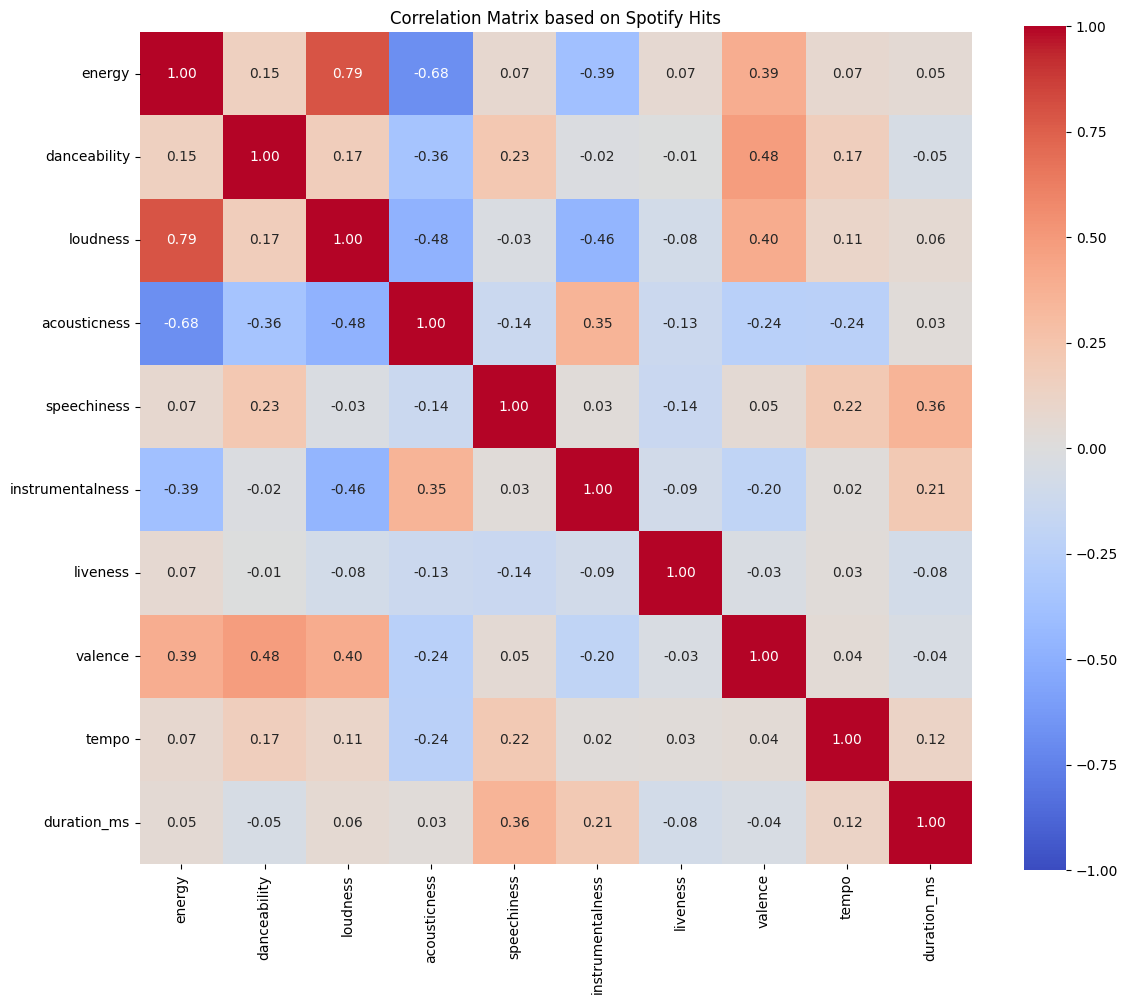

In [24]:
# Visualize the correlation matrix with a simple heatmap using plt and seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_tracks_dataset, annot=True, cmap="coolwarm", center=0, 
            square=True, fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix based on Spotify Hits")
plt.tight_layout()
plt.show()

***Short Heatmap Analysis:***

`From range red to blue with red being r = 1 and blue r = -1 (correlation scores), strong positive vs strong negative correlation.`

You can see that `energy and loudness are strongly positively correlated (0.79)` - energetic tracks tend to be louder. Conversely, `energy and acousticness show strong (nearly -0.7) negative correlation (-0.68)` - acoustic songs are typically lower energy.
The data reveals two main clusters: `high-energy/loud/danceable tracks versus quiet/acoustic/instrumental songs.` `Most other correlations are moderate.` You can see this results as well as results of our feature comparison functions above.


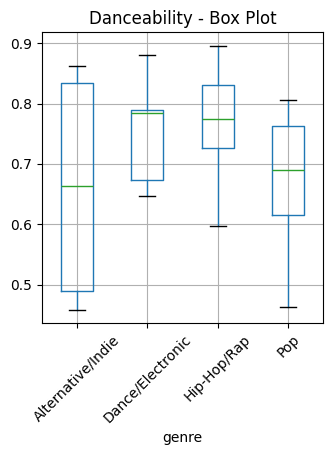

                   count      mean       std    min      25%    50%      75%  \
genre                                                                          
Alternative/Indie    4.0  0.661750  0.211107  0.459  0.49050  0.663  0.83425   
Dance/Electronic     5.0  0.755000  0.094744  0.647  0.67400  0.785  0.78900   
Hip-Hop/Rap         13.0  0.765538  0.085470  0.598  0.72600  0.774  0.83000   
Pop                 14.0  0.677571  0.109853  0.464  0.61575  0.690  0.76275   

                     max  
genre                     
Alternative/Indie  0.862  
Dance/Electronic   0.880  
Hip-Hop/Rap        0.896  
Pop                0.806  


In [25]:
# Function and preparation for feature comparison
genre_dataset_tracks = tracks_dataset[tracks_dataset["genre"].isin(TARGET_GENRES)].copy()

def genre_comparison(data: pd.DataFrame, feature: str) -> pd.DataFrame:
    """
    Comparison between features by calculating min, max, mean, std based on given dataframe and feature.
    Afterwards creating a simple boxplot to showcase comparisons.
    """
    genre_statistics: pd.DataFrame = data.groupby("genre")[feature].describe()
    # Box Plot
    plt.subplot(1, 2, 1)
    data.boxplot(column=feature, by="genre", ax=plt.gca())
    plt.title(f"{feature.capitalize()} - Box Plot")
    plt.suptitle("")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    return genre_statistics

# How does the danceability score compare between Pop, Hip-Hop/Rap, Dance/Electronic, and Alternative/Indie genres?
danceability_comparison = genre_comparison(genre_dataset_tracks, "danceability")
print(danceability_comparison)

***Short Danceability Boxplot Analysis:***

`Hip-Hop/Rap has the highest average danceability (0.765)`, followed closely by `Dance/Electronic (0.755).` `Pop and Alternative/Indie score lower (around 0.67-0.68).`
What's notable is that `Alternative/Indie shows the widest variability` - ranging from 0.49 to 0.86 with high standard deviation (0.20), indicating this genre spans from very non-danceable to highly danceable tracks. `Dance/Electronic and Hip-Hop/Rap are more consistently` danceable with tighter distributions and smaller standard deviations.


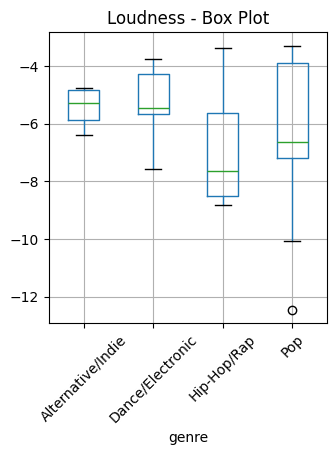

                   count      mean       std     min      25%     50%  \
genre                                                                   
Alternative/Indie    4.0 -5.421000  0.774502  -6.401 -5.85950 -5.2685   
Dance/Electronic     5.0 -5.338000  1.479047  -7.567 -5.65200 -5.4570   
Hip-Hop/Rap         13.0 -6.917846  1.891808  -8.820 -8.52000 -7.6480   
Pop                 14.0 -6.317429  2.628893 -12.453 -7.17875 -6.6445   

                       75%    max  
genre                              
Alternative/Indie -4.83000 -4.746  
Dance/Electronic  -4.25800 -3.756  
Hip-Hop/Rap       -5.61600 -3.370  
Pop               -3.87525 -3.280  


In [26]:
# How does the loudness score compare between Pop, Hip-Hop/Rap, Dance/Electronic, and Alternative/Indie genres?
loudness_comparison = genre_comparison(genre_dataset_tracks, "loudness")
print(loudness_comparison)

***Short Loudness Boxplot Analysis:***

On average, `Alternative/Indie and Dance/Electronic tracks (means around -5.3 to -5.4) in the dataset tend to be louder than Hip-Hop/Rap and Pop (means around -6.3 to -6.9).`
What stands out is that `Pop shows the widest range - from nearly the loudest song at -3.28 to the quietest at -12.5`, with high variability `(std = 2.63)`. Hip-Hop/Rap is consistently quieter with the lowest average loudness (-6.92) but more consistent levels. The boxplot reveals Pop has the most diverse loudness characteristics, while Alternative/Indie maintains the most consistent louder levels.

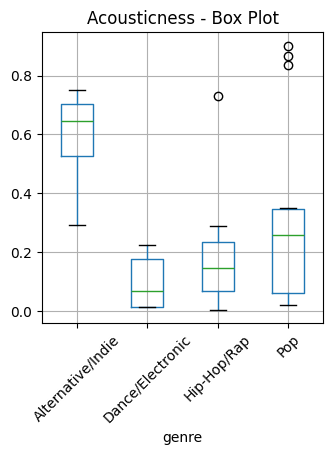

                   count      mean       std      min      25%     50%  \
genre                                                                    
Alternative/Indie    4.0  0.583500  0.204086  0.29100  0.52575  0.6460   
Dance/Electronic     5.0  0.099440  0.095828  0.01370  0.01490  0.0686   
Hip-Hop/Rap         13.0  0.188741  0.186396  0.00513  0.06700  0.1450   
Pop                 14.0  0.323843  0.318142  0.02100  0.05990  0.2590   

                       75%    max  
genre                              
Alternative/Indie  0.70375  0.751  
Dance/Electronic   0.17700  0.223  
Hip-Hop/Rap        0.23400  0.731  
Pop                0.34800  0.902  


In [27]:
# How does the acousticness score compare between Pop, Hip-Hop/Rap, Dance/Electronic, and Alternative/Indie genres?
acousticness_comparison = genre_comparison(genre_dataset_tracks, "acousticness")
print(acousticness_comparison)

***Short Acousticness Boxplot Analysis***: 

You can see that Alternative/Indie tracks in the dataset tend to be more acoustic (mean = 0.558) than the other compared genres. What stands out is that `Pop has a lot of outliers in the range of 0.9, which is much higher than its average 0.32.` 

**Acousticness:** `Alternative/Indie > Pop > Hip-Hop/Rap > Dance/Electronic`

## Results overview
#### Data Cleaning: 
50 tracks, 16 features. No missing values, no duplicate rows/columns detected, no duplicate features. Treated the artists, albums, track_names all as titles for consistency.
#### Data Analysis:
- **Data**
   - Number of observations: 50
   - Number of features: 16
   - Categorical features: ['artist', 'album', 'track_name', 'track_id', 'genre']
   - Numeric features: ['energy', 'danceability', 'key', 'loudness', 'acousticness', 'speechiness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']
- **Artists**
  - Most popular artist (by weighted ranking): Lewis Capaldi (2 songs, 75 total points)
  - Artist with >1 track: Billie Eilish (3), Dua Lipa (3), Travis Scott (3), Justin Bieber (2), Harry Styles (2), Lewis Capaldi (2), Post Malone (2)
  - Total number of unique artists: 40
  - Artist with the most popular song (rank #1): The Weeknd
- **Albums**
  - Total number of unique albums: 45
  - Albums with >1 track: Future Nostalgia (3), Hollywood's Bleeding (2), Fine Line (2), Changes (2)
- **Tracks**
  - Longest track: Sicko Mode
  - Shortest track: Mood (Feat. Iann Dior)
  - Danceability: Many tracks score high (> 0.7), only Lovely (With Khalid) < 0.4
  - Loudness: Many tracks are mastered loud (> -5 dB); a minority are very quiet (< -8 dB)
- **Genre**
  - Most represented genre: Pop
  - Total number of genres: 16
  - Genres with only one song: ['Nu-Disco', 'R&B/Hip-Hop Alternative', 'Pop/Soft Rock', 'Pop Rap', 'Hip-Hop/Trap', 'Dance-Pop/Disco', 'Disco-Pop', 'Dreampop/Hip-Hop/R&B', 'Alternative/Reggaeton/Experimental', 'Chamber Pop']
- **Feature Analysis**
  - Correlation highlights: energy correlates strongly with loudness (r ≈ 0.79); no strong negative correlations (≤ -0.7) - although energetic songs tend to be less acoustic (r ≈ -0.68) as seen in the heatmap
  - Weak associations: most other pairs show weak correlations (|r| ≤ 0.3); a more detailed overview can be seen in the heatmap 
  - Genre comparisons:
    - Danceability (mean): Hip-Hop/Rap 0.766, Dance/Electronic 0.755, Pop 0.678, Alternative/Indie 0.662
    - Loudness (mean dB): Dance/Electronic -5.338, Alternative/Indie -5.421, Pop -6.460, Hip-Hop/Rap -6.918
    - Acousticness (mean): Alternative/Indie 0.584 > Pop 0.324 > Hip-Hop/Rap 0.189 > Dance/Electronic 0.099
    
    You can see the whole comparison as boxplots above as well as some short further analysis. 


## Interpretation
- **Hit characteristics**
  - High danceability and energetic as well as loudness characterize many hits. Energy and loudness go hand-in-hand (strong positive correlation).
  - Genre mix: Pop leads overall presence, but Hip-Hop/Rap and Dance/Electronic contribute many highly danceable, energetic tracks.
  - Length is not decisive on its own: hits range from very short ("Mood") to long ("Sicko Mode").
  - Not key drivers: key, tempo, and liveness show weak links with success within this set.
  - The genre comparisons show that each genre within the Top 50 exhibits its own audio feature profile (e.g., higher danceability in Hip-Hop/Rap, lower acousticness in Dance/Electronic).
- **Notes**
  - Correlations or comparisons do not necessarly imply causation. The sample is the Top 50 at a given time and may reflect period-specific trends and Spotify's audio feature definitions. This is true for the analysis as a whole, cause a lot of external factors arent reflected in the dataset. 